   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


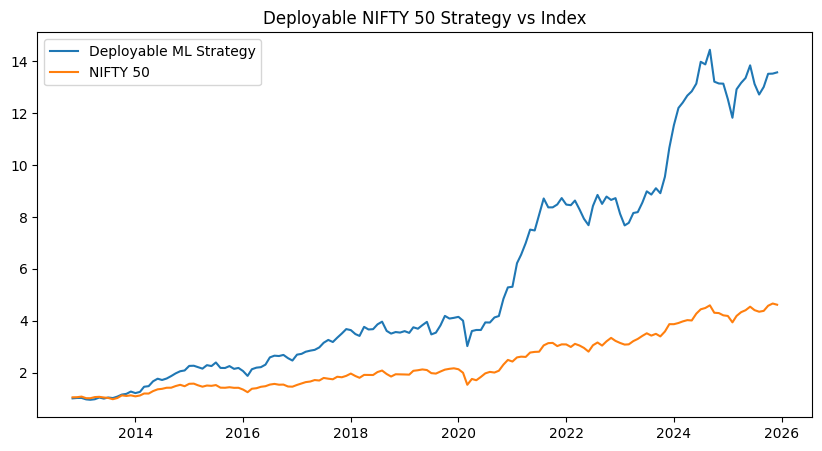

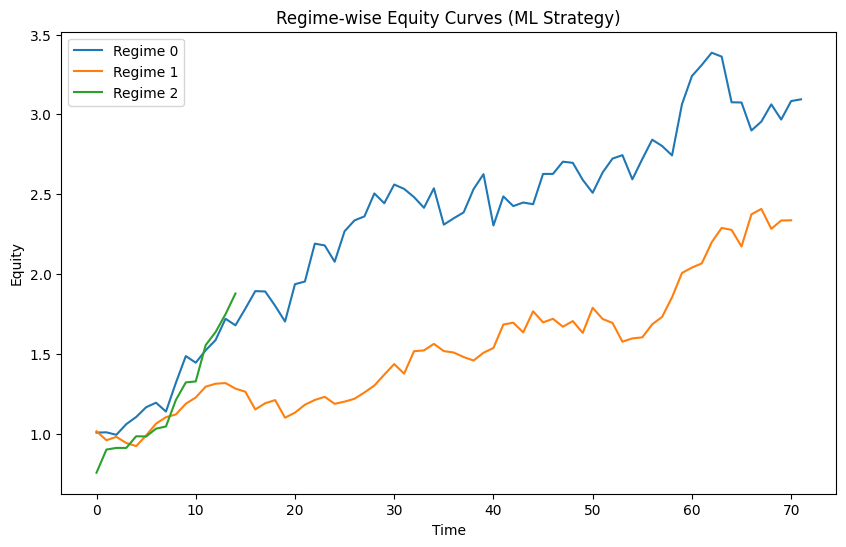

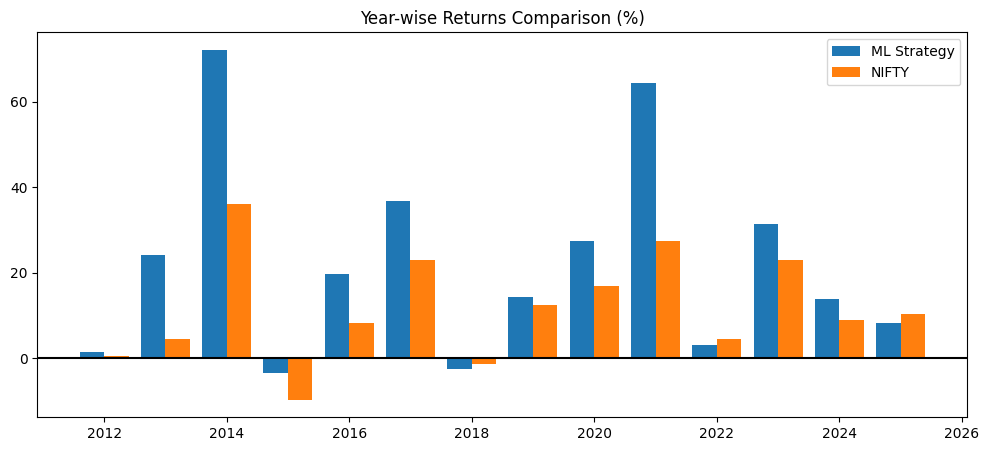


===== YEAR-WISE RETURNS (%) =====
      ML_Return  NIFTY_Return
year                         
2012       1.47          0.43
2013      23.99          4.46
2014      72.13         36.02
2015      -3.46         -9.79
2016      19.65          8.23
2017      36.62         23.00
2018      -2.61         -1.50
2019      14.25         12.35
2020      27.37         16.88
2021      64.42         27.28
2022       2.94          4.41
2023      31.31         23.04
2024      13.87          8.83
2025       8.26         10.35

=========== RISK REPORT ===========
Metric             ML Strategy       NIFTY 50
---------------------------------------------
CAGR                    21.91%         12.32%
Sharpe                    1.12           0.83
Max DD                 -27.82%        -29.34%
Hit Rate                65.82%         58.86%

===== REGIME-WISE PERFORMANCE METRICS =====
regime              
0       CAGR (%)        20.72
        Sharpe           1.11
        Max DD (%)     -14.38
        Hit Rate

In [ ]:
# ============================================================
# FINAL DEPLOYABLE NIFTY 50 STRATEGY
# ============================================================

!pip install hmmlearn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBRanker


# ================= CONFIG =================
START_DATE = "2005-01-01"
TOP_K = 10
TRAIN_MONTHS = 60
RETRAIN_FREQ = 12
EXEC_DELAY = 1

TARGET_VOL = 0.14
MAX_EXPOSURE = 1.0
MAX_WEIGHT = 0.12

SLIPPAGE = 0.001
IMPACT = 0.0005
# =========================================


# ============================================================
# STEP 1 — NIFTY 50 INDEX
# ============================================================
nifty = yf.download("^NSEI", start=START_DATE, interval="1mo",
                    auto_adjust=True, progress=False)
nifty.columns = nifty.columns.get_level_values(0)
nifty = nifty[["Close"]].rename(columns={"Close":"nifty"})
nifty["ret"] = nifty["nifty"].pct_change()
nifty.dropna(inplace=True)
nifty.reset_index(inplace=True)
nifty.rename(columns={"Date":"date"}, inplace=True)


# ============================================================
# STEP 2 — ALL NIFTY 50 STOCKS
# ============================================================
NIFTY50 = [
 "ADANIENT.NS","ADANIPORTS.NS","APOLLOHOSP.NS","ASIANPAINT.NS",
 "AXISBANK.NS","BAJAJ-AUTO.NS","BAJAJFINSV.NS","BAJFINANCE.NS",
 "BHARTIARTL.NS","BPCL.NS","BRITANNIA.NS","CIPLA.NS",
 "COALINDIA.NS","DIVISLAB.NS","DRREDDY.NS","EICHERMOT.NS",
 "GRASIM.NS","HCLTECH.NS","HDFCBANK.NS","HDFCLIFE.NS",
 "HINDALCO.NS","HINDUNILVR.NS","ICICIBANK.NS","INFY.NS",
 "ITC.NS","JSWSTEEL.NS","KOTAKBANK.NS","LT.NS","MARUTI.NS",
 "NESTLEIND.NS","NTPC.NS","ONGC.NS","POWERGRID.NS",
 "RELIANCE.NS","SBIN.NS","SBILIFE.NS","SHRIRAMFIN.NS",
 "SUNPHARMA.NS","TATACONSUM.NS","TATAMOTORS.NS","TATASTEEL.NS",
 "TCS.NS","TECHM.NS","TITAN.NS","ULTRACEMCO.NS","WIPRO.NS"
]

frames = []
for s in NIFTY50:
    df = yf.download(s, start=START_DATE, interval="1mo",
                     auto_adjust=True, progress=False)
    if df.empty:
        continue
    df.columns = df.columns.get_level_values(0)
    df = df[["Close"]].rename(columns={"Close":"price"})
    df["stock"] = s
    df.reset_index(inplace=True)
    df.rename(columns={"Date":"date"}, inplace=True)
    frames.append(df)

stocks = pd.concat(frames)
stocks = stocks.merge(nifty[["date","ret"]], on="date", how="left")


# ============================================================
# STEP 3 — FEATURES
# ============================================================
stocks["ret_1m"] = stocks.groupby("stock")["price"].pct_change()
stocks["mom_6m"] = stocks.groupby("stock")["price"].pct_change(6)
stocks["vol_12m"] = stocks.groupby("stock")["ret_1m"] \
                          .rolling(12).std().reset_index(0,drop=True)
stocks.dropna(inplace=True)


# ============================================================
# STEP 4 — REGIME (SOFT)
# ============================================================
factors = stocks.groupby("date")[["ret_1m","mom_6m","vol_12m"]].mean()
X = StandardScaler().fit_transform(factors)

hmm = GaussianHMM(n_components=3, n_iter=500, random_state=42)
hmm.fit(X)
factors["regime"] = hmm.predict(X)

stocks = stocks.merge(factors["regime"], on="date", how="left")

SECTOR_MAP = {
    "ADANIENT.NS":"Energy","ADANIPORTS.NS":"Energy",
    "RELIANCE.NS":"Energy","ONGC.NS":"Energy","BPCL.NS":"Energy",
    "COALINDIA.NS":"Energy","POWERGRID.NS":"Utilities","NTPC.NS":"Utilities",

    "HDFCBANK.NS":"Financials","ICICIBANK.NS":"Financials","SBIN.NS":"Financials",
    "KOTAKBANK.NS":"Financials","AXISBANK.NS":"Financials",
    "BAJFINANCE.NS":"Financials","BAJAJFINSV.NS":"Financials",
    "SBILIFE.NS":"Financials","HDFCLIFE.NS":"Financials","SHRIRAMFIN.NS":"Financials",

    "INFY.NS":"IT","TCS.NS":"IT","WIPRO.NS":"IT","TECHM.NS":"IT","HCLTECH.NS":"IT",

    "HINDUNILVR.NS":"FMCG","ITC.NS":"FMCG","NESTLEIND.NS":"FMCG",
    "BRITANNIA.NS":"FMCG","TATACONSUM.NS":"FMCG",

    "MARUTI.NS":"Auto","TATAMOTORS.NS":"Auto","EICHERMOT.NS":"Auto",
    "BAJAJ-AUTO.NS":"Auto",

    "ULTRACEMCO.NS":"Cement","GRASIM.NS":"Cement",

    "ASIANPAINT.NS":"Consumer","TITAN.NS":"Consumer",

    "SUNPHARMA.NS":"Pharma","DRREDDY.NS":"Pharma","DIVISLAB.NS":"Pharma","CIPLA.NS":"Pharma",

    "JSWSTEEL.NS":"Metals","TATASTEEL.NS":"Metals","HINDALCO.NS":"Metals"
}
# ============================================================
# STEP 5 — WALK-FORWARD STRATEGY (FINAL, DEPLOYABLE)
# ============================================================

dates = sorted(stocks["date"].unique())
portfolio_returns = []
portfolio_dates = []

ranker = None
prev_weights = None

for i in range(TRAIN_MONTHS, len(dates) - EXEC_DELAY):

    # --------------------------------------------------------
    # Retrain ranking model (rolling, frozen between retrains)
    # --------------------------------------------------------
    if (i - TRAIN_MONTHS) % RETRAIN_FREQ == 0:
        train = stocks[stocks["date"] < dates[i]]

        ranker = XGBRanker(
            objective="rank:pairwise",
            n_estimators=150,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8
        )

        ranker.fit(
            train[["mom_6m", "vol_12m"]],
            train["ret_1m"],
            group=train.groupby("date").size().values
        )

    # --------------------------------------------------------
    # Score today’s universe
    # --------------------------------------------------------
    today = stocks[stocks["date"] == dates[i]].copy()
    today["score"] = ranker.predict(today[["mom_6m", "vol_12m"]])

    # --------------------------------------------------------
    # Asymmetric volatility targeting (safe)
    # --------------------------------------------------------
    realized_vol = nifty.loc[nifty["date"] == dates[i], "ret"].rolling(12).std().iloc[0]
    long_term_vol = nifty["ret"].rolling(36).std().loc[nifty["date"] == dates[i]].iloc[0]

    # Numerical safety
    realized_vol = max(realized_vol, 1e-4)
    long_term_vol = max(long_term_vol, 1e-4)

    vol_ratio = realized_vol / long_term_vol

    if vol_ratio < 0.75:          # very calm
        exposure = min(1.20, TARGET_VOL / (realized_vol * np.sqrt(12)))
    elif vol_ratio < 0.90:        # normal bull
        exposure = min(1.10, TARGET_VOL / (realized_vol * np.sqrt(12)))
    else:                         # stressed
        exposure = min(1.00, TARGET_VOL / (realized_vol * np.sqrt(12)))

    # --------------------------------------------------------
    # Portfolio construction
    # --------------------------------------------------------
    top = today.sort_values("score", ascending=False).head(TOP_K).copy()

    # Base weights: inverse volatility
    w = 1 / top["vol_12m"]
    w /= w.sum()

    # Confidence-based concentration
    score_dispersion = top["score"].std()
    score_mean = abs(top["score"].mean())

    if score_dispersion > 0.8 * score_mean:
        max_w = 0.18   # strong alpha
    else:
        max_w = 0.12   # weak alpha

    # Apply stock cap
    w = w.clip(upper=max_w)
    w /= w.sum()

    # --------------------------------------------------------
    # Sector caps (institutional constraint)
    # --------------------------------------------------------
    top["sector"] = top["stock"].map(SECTOR_MAP).fillna("Other")
    SECTOR_CAP = 0.30

    sector_weights = top.groupby("sector").apply(lambda x: w.loc[x.index].sum())

    for sector, sw in sector_weights.items():
        if sw > SECTOR_CAP:
            idx = top[top["sector"] == sector].index
            w.loc[idx] *= SECTOR_CAP / sw

    w /= w.sum()

    # --------------------------------------------------------
    # Turnover-based transaction impact
    # --------------------------------------------------------
    turnover = 0.0
    if prev_weights is not None:
        turnover = np.sum(np.abs(w.values - prev_weights))

    prev_weights = w.values.copy()

    # --------------------------------------------------------
    # Execution (T+1)
    # --------------------------------------------------------
    next_m = stocks[stocks["date"] == dates[i + EXEC_DELAY]]

    realized = (
        next_m
        .set_index("stock")
        .reindex(top["stock"])
        ["ret_1m"]
        .fillna(0.0)
    )

    # --------------------------------------------------------
    # Beta overlay when alpha is very weak
    # --------------------------------------------------------
    alpha_strength = top["score"].mean()
    beta_overlay = 0.30 if alpha_strength < 0.05 else 0.0

    beta_ret = nifty.loc[nifty["date"] == dates[i + EXEC_DELAY], "ret"].iloc[0]

    # --------------------------------------------------------
    # Net portfolio return
    # --------------------------------------------------------
    net_ret = (
        exposure * np.sum(w.values * realized.values)
        + beta_overlay * beta_ret
        - SLIPPAGE
        - IMPACT * turnover
    )

    portfolio_returns.append(net_ret)
    portfolio_dates.append(dates[i + EXEC_DELAY])

# ============================================================
# STEP 6 — EQUITY CURVES (ALIGNED)
# ============================================================
pf = pd.Series(portfolio_returns, index=portfolio_dates)
bm = nifty.set_index("date").loc[pf.index, "ret"]

ml_eq = (1 + pf).cumprod()
bm_eq = (1 + bm).cumprod()

plt.figure(figsize=(10,5))
plt.plot(ml_eq, label="Deployable ML Strategy")
plt.plot(bm_eq, label="NIFTY 50")
plt.legend()
plt.title("Deployable NIFTY 50 Strategy vs Index")
plt.show()

# ============================================================
# STEP 6B — REGIME-WISE EQUITY CURVES
# ============================================================

regime_returns = pd.DataFrame({
    "date": pf.index,
    "ret": pf.values
}).merge(
    factors["regime"], left_on="date", right_index=True, how="left"
)

plt.figure(figsize=(10,6))

for r in sorted(regime_returns["regime"].dropna().unique()):
    eq = (1 + regime_returns[regime_returns["regime"] == r]["ret"]).cumprod()
    plt.plot(eq.values, label=f"Regime {r}")

plt.legend()
plt.title("Regime-wise Equity Curves (ML Strategy)")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.show()

# ============================================================
# STEP 7 — YEAR-WISE RETURNS (FIXED)
# ============================================================
df = pd.DataFrame({
    "date": ml_eq.index,
    "ML": ml_eq.values,
    "NIFTY": bm_eq.values
})
df["year"] = df["date"].dt.year

yearly = df.groupby("year").apply(
    lambda x: pd.Series({
        "ML_Return": x["ML"].iloc[-1]/x["ML"].iloc[0] - 1,
        "NIFTY_Return": x["NIFTY"].iloc[-1]/x["NIFTY"].iloc[0] - 1
    })
)

plt.figure(figsize=(12,5))
plt.bar(yearly.index-0.2, yearly["ML_Return"]*100, width=0.4, label="ML Strategy")
plt.bar(yearly.index+0.2, yearly["NIFTY_Return"]*100, width=0.4, label="NIFTY")
plt.axhline(0, color="black")
plt.legend()
plt.title("Year-wise Returns Comparison (%)")
plt.show()

print("\n===== YEAR-WISE RETURNS (%) =====")
print((yearly*100).round(2))


# ============================================================
# STEP 8 — RISK REPORT
# ============================================================
def risk_report(returns):
    cagr = (1+returns).prod()**(12/len(returns)) - 1
    sharpe = returns.mean()/returns.std()*np.sqrt(12)
    dd = (1+returns).cumprod()/((1+returns).cumprod().cummax()) - 1
    max_dd = dd.min()
    hit_rate = (returns > 0).mean()
    return cagr, sharpe, max_dd, hit_rate

ml_c, ml_s, ml_dd, ml_hr = risk_report(pf)
bm_c, bm_s, bm_dd, bm_hr = risk_report(bm)

print("\n=========== RISK REPORT ===========")
print(f"{'Metric':<15}{'ML Strategy':>15}{'NIFTY 50':>15}")
print("-"*45)
print(f"{'CAGR':<15}{ml_c*100:>14.2f}%{bm_c*100:>14.2f}%")
print(f"{'Sharpe':<15}{ml_s:>15.2f}{bm_s:>15.2f}")
print(f"{'Max DD':<15}{ml_dd*100:>14.2f}%{bm_dd*100:>14.2f}%")
print(f"{'Hit Rate':<15}{ml_hr*100:>14.2f}%{bm_hr*100:>14.2f}%")

# ============================================================
# STEP 8B — REGIME-WISE PERFORMANCE METRICS
# ============================================================

def perf_metrics(x):
    cagr = (1+x).prod()**(12/len(x)) - 1
    sharpe = x.mean()/x.std()*np.sqrt(12)
    dd = (1+x).cumprod()/((1+x).cumprod().cummax()) - 1
    return pd.Series({
        "CAGR (%)": cagr*100,
        "Sharpe": sharpe,
        "Max DD (%)": dd.min()*100,
        "Hit Rate (%)": (x>0).mean()*100
    })

regime_perf = (
    regime_returns
    .dropna()
    .groupby("regime")["ret"]
    .apply(perf_metrics)
    .round(2)
)

print("\n===== REGIME-WISE PERFORMANCE METRICS =====")
print(regime_perf)

# ============================================================
# STEP 9 — REGIME-WISE STOCK RECOMMENDATIONS
# ============================================================

latest_date = stocks["date"].max()
latest = stocks[stocks["date"] == latest_date].copy()
latest["score"] = ranker.predict(latest[["mom_6m","vol_12m"]])

print("\n===== REGIME-WISE STOCK RECOMMENDATIONS =====")

for r in sorted(latest["regime"].unique()):
    sub = latest[latest["regime"] == r]
    if len(sub) < TOP_K:
        continue

    picks = sub.sort_values("score", ascending=False).head(TOP_K)

    print(f"\n--- Regime {r} ---")
    print(
        picks[["stock","mom_6m","vol_12m","score"]]
        .reset_index(drop=True)
    )